Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
import shap

Loading the data and model

In [5]:
xgb_best = joblib.load('../models/xgboost_best.pkl')
thresholds = joblib.load('../models/xgb_threshold.pkl')
best_threshold_xgb = thresholds['xgb_threshold']

X_val    = pd.read_parquet('../data/processed/X_val.parquet')
X_test   = pd.read_parquet('../data/processed/X_test.parquet')
y_val    = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']
y_test   = pd.read_parquet('../data/processed/y_test.parquet')['isFraud']

SHAP TreeExplainer for XGBoost

In [8]:
explainer = shap.TreeExplainer(xgb_best)

np.random.seed(42)
sample_idx = np.random.choice(len(X_val) , size = 5000 , replace = False)
X_sample = X_val.iloc[sample_idx]
y_sample = y_val.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)

In [11]:
shap_values

array([[-1.1837853e-01,  2.5575910e-02, -7.2184317e-02, ...,
        -3.8060753e+00,  6.3669807e-03, -1.6154575e-01],
       [-8.7243721e-02,  3.2766303e-01,  2.5962788e-01, ...,
         1.1445813e+00, -1.7898045e-02, -1.3156310e-01],
       [ 3.1247526e-01, -5.4265583e-01, -3.4949847e-02, ...,
         6.9309914e-01,  2.0329640e-03, -1.6528508e-02],
       ...,
       [ 2.9689813e-01, -3.8157515e-03, -1.0358458e-01, ...,
        -3.1256900e+00,  6.3977249e-02, -7.9501234e-04],
       [ 1.8376541e-01, -2.0721024e-02, -1.4282069e-01, ...,
        -1.9862444e+00,  9.8320795e-03, -4.9575843e-02],
       [ 2.8398570e-02,  4.5394585e-02,  3.7086585e-03, ...,
        -1.8033230e+00, -2.0281537e-02,  3.7259933e-02]],
      shape=(5000, 216), dtype=float32)

In [12]:
print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (average prediction): {explainer.expected_value:.4f}")
print(f"Actual fraud rate in sample:     {y_sample.mean()*100:.2f}%")

SHAP values shape: (5000, 216)
Base value (average prediction): 0.0400
Actual fraud rate in sample:     3.82%


SHAP summary plot (Beeswarm)

C:\Users\bhaav\AppData\Local\Temp\ipykernel_5420\2944069141.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


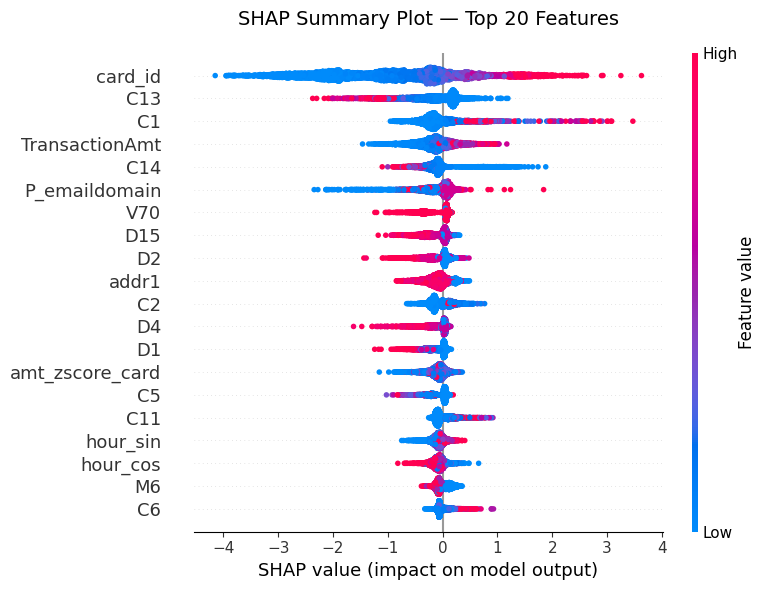

In [17]:
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,        # show top 20 features
    show=False,
    plot_size=(8, 6)
)
plt.title('SHAP Summary Plot — Top 20 Features', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../reports/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Waterfall Plots

In [19]:
# Get predictions on full validation set
xgb_proba_val = xgb_best.predict_proba(X_val)[:, 1]
xgb_preds_val = (xgb_proba_val >= best_threshold_xgb).astype(int)

# Case 1 — High confidence fraud (TP): actually fraud, predicted fraud
tp_idx = np.where((y_val == 1) & (xgb_preds_val == 1))[0]
high_conf_fraud_idx = tp_idx[np.argsort(xgb_proba_val[tp_idx])[-1]]

# Case 2 — Borderline case: fraud probability close to threshold
borderline_idx = np.argmin(np.abs(xgb_proba_val - best_threshold_xgb))

# Case 3 — False positive (FP): legitimate transaction flagged as fraud
fp_idx = np.where((y_val == 0) & (xgb_preds_val == 1))[0]
false_positive_idx = fp_idx[np.argsort(xgb_proba_val[fp_idx])[-1]]

print(f"High confidence fraud idx:  {high_conf_fraud_idx}, proba: {xgb_proba_val[high_conf_fraud_idx]:.4f}")
print(f"Borderline case idx:        {borderline_idx}, proba: {xgb_proba_val[borderline_idx]:.4f}")
print(f"False positive idx:         {false_positive_idx}, proba: {xgb_proba_val[false_positive_idx]:.4f}")

High confidence fraud idx:  63904, proba: 1.0000
Borderline case idx:        27561, proba: 0.8294
False positive idx:         56164, proba: 0.9999


In [22]:
cases = {
    'high_confidence_fraud': high_conf_fraud_idx,
    'borderline_case':       borderline_idx,
    'false_positive':        false_positive_idx
}
shap_cases = {}
for name , idx in cases.items():
    transaction = X_val.iloc[[idx]]
    sv = explainer.shap_values(transaction)
    shap_cases[name] = {
        'shap_values': sv[0],
        'transaction': transaction,
        'prediction':  xgb_proba_val[idx],
        'actual':      y_val.iloc[idx]
    }
    print(f"{name}: proba={xgb_proba_val[idx]:.4f}, actual={'FRAUD' if y_val.iloc[idx]==1 else 'LEGIT'}")

high_confidence_fraud: proba=1.0000, actual=FRAUD
borderline_case: proba=0.8294, actual=FRAUD
false_positive: proba=0.9999, actual=LEGIT


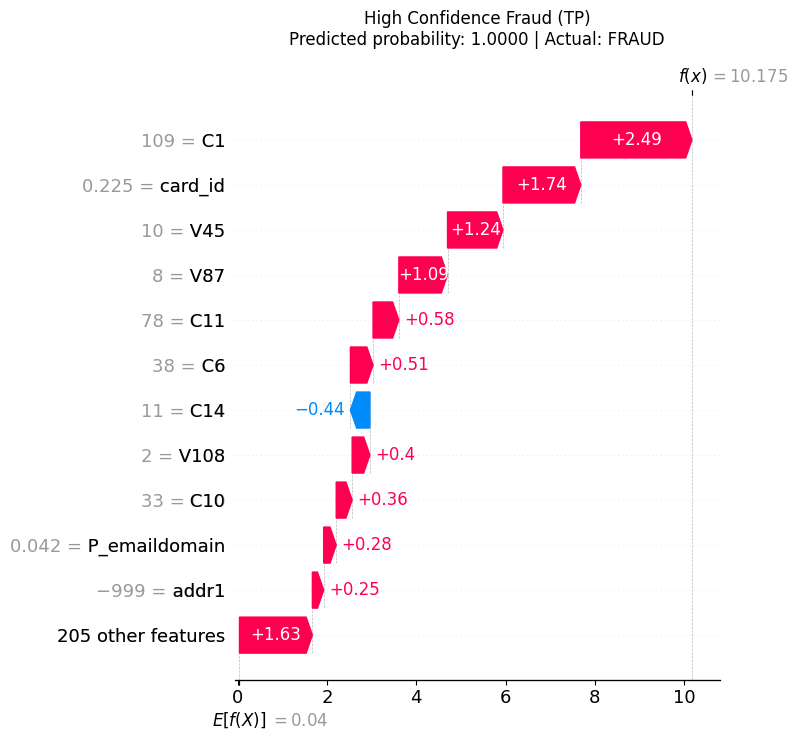

Saved: reports/shap_waterfall_high_confidence_fraud.png


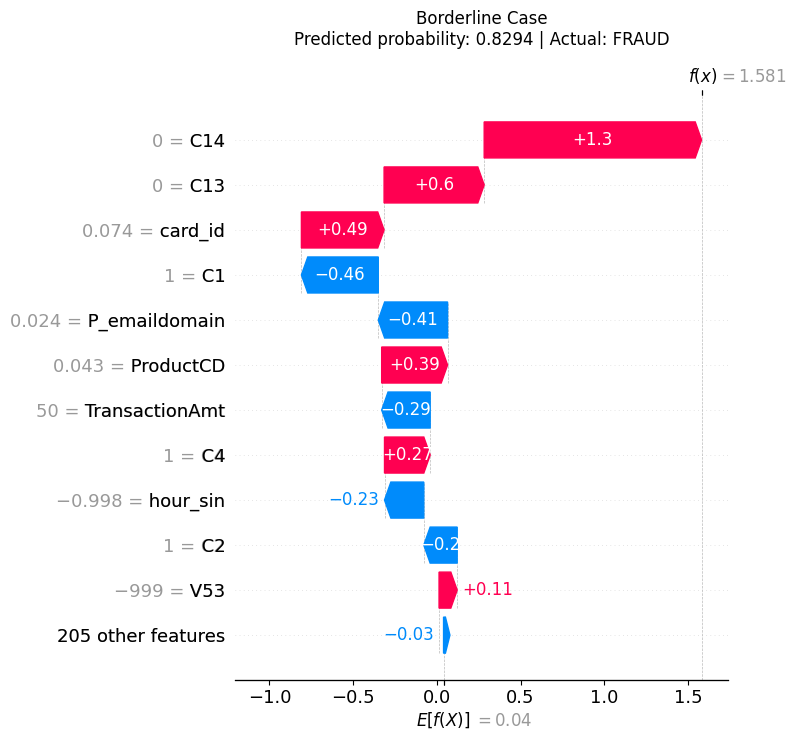

Saved: reports/shap_waterfall_borderline_case.png


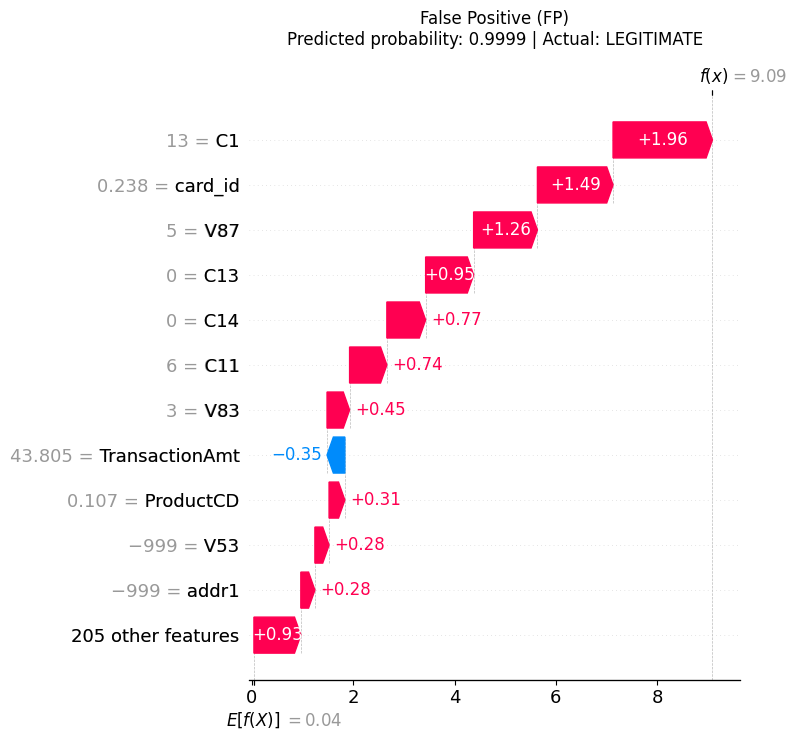

Saved: reports/shap_waterfall_false_positive.png


In [29]:
cases_list = [
    ('high_confidence_fraud', 'High Confidence Fraud (TP)'),
    ('borderline_case',       'Borderline Case'),
    ('false_positive',        'False Positive (FP)')
]

for name, title in cases_list:
    data = shap_cases[name]
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(
        shap.Explanation(
            values=data['shap_values'],
            base_values=explainer.expected_value,
            data=data['transaction'].values[0],
            feature_names=X_val.columns.tolist()
        ),
        max_display=12,
        show=False
    )
    plt.title(
        f"{title}\n"
        f"Predicted probability: {data['prediction']:.4f} | "
        f"Actual: {'FRAUD' if data['actual']==1 else 'LEGITIMATE'}",
        fontsize=12, pad=15
    )
    plt.tight_layout()
    plt.savefig(f'../reports/shap_waterfall_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: reports/shap_waterfall_{name}.png")

Plain English interpretation

In [30]:
# Generate business-readable explanation for each case
def explain_transaction(name, data, top_n=5):
    sv    = data['shap_values']
    feats = X_val.columns.tolist()
    vals  = data['transaction'].values[0]

    # Get top features by absolute SHAP value
    top_idx = np.argsort(np.abs(sv))[::-1][:top_n]
    print(f"\nCase: {name.upper().replace('_',' ')}")
    print(f"Fraud probability: {data['prediction']:.4f}")
    print(f"Actual label: {'FRAUD' if data['actual']==1 else 'LEGITIMATE'}")
    print(f"Base value (avg prediction): {explainer.expected_value:.4f}")
    print(f"\nTop {top_n} contributing features:")
    print(f"{'Feature':<25} {'SHAP Value':>12} {'Direction':>12}")
    print("-" * 52)

    for idx in top_idx:
        direction = "→ FRAUD" if sv[idx] > 0 else "→ NOT FRAUD"
        print(f"{feats[idx]:<25} {sv[idx]:>12.4f} {direction:>12}")

for name, data in shap_cases.items():
    explain_transaction(name, data)


Case: HIGH CONFIDENCE FRAUD
Fraud probability: 1.0000
Actual label: FRAUD
Base value (avg prediction): 0.0400

Top 5 contributing features:
Feature                     SHAP Value    Direction
----------------------------------------------------
C1                              2.4900      → FRAUD
card_id                         1.7432      → FRAUD
V45                             1.2417      → FRAUD
V87                             1.0905      → FRAUD
C11                             0.5777      → FRAUD

Case: BORDERLINE CASE
Fraud probability: 0.8294
Actual label: FRAUD
Base value (avg prediction): 0.0400

Top 5 contributing features:
Feature                     SHAP Value    Direction
----------------------------------------------------
C14                             1.2986      → FRAUD
C13                             0.5979      → FRAUD
card_id                         0.4939      → FRAUD
C1                             -0.4593  → NOT FRAUD
P_emaildomain                  -0.4139  → NOT 

In [32]:
# Get global feature importance from SHAP
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_val.columns
).sort_values(ascending=False)

print("Top 15 features by mean |SHAP value| with business interpretation:")
print(f"\n{'Feature':<25} {'Mean |SHAP|':>12}  Business Meaning")
print("-" * 80)

# Manual interpretation for key features
interpretations = {
    'card_id':          'Composite card identity — card history and fraud rate signal',
    'card_id_te':       'Card-level historical fraud rate',
    'C1':               'Vesta count feature — likely address or card occurrence count',
    'C2':               'Vesta count feature — likely email or device occurrence count',
    'C4':               'Vesta count feature',
    'C5':               'Vesta count feature',
    'C6':               'Vesta count feature',
    'C11':              'Vesta count feature — strong fraud signal in all three cases',
    'C13':              'Vesta count feature — appears in all three waterfall cases',
    'C14':              'Vesta count feature — bidirectional signal (fraud and not-fraud)',
    'TransactionAmt':   'Raw transaction amount — higher amounts increase fraud risk',
    'amt_zscore_card':  'Amount unusualness for this card — behavioral anomaly score',
    'P_emaildomain':    'Purchaser email domain — protonmail and high-risk domains flagged',
    'P_emaildomain_te': 'Purchaser email domain fraud rate',
    'ProductCD_te':     'Product type fraud rate — product C highest risk (11.7%)',
    'V70':              'Vesta engineered feature — transaction risk signal',
    'D1':               'Days since last transaction for this card',
    'D2':               'Days since last address change',
    'D4':               'Days since last email change',
    'D15':              'Days since last transaction for this address',
    'addr1':            'Billing address — location-based fraud pattern',
    'hour_sin':         'Time of day (cyclic sine) — certain hours more suspicious',
    'hour_cos':         'Time of day (cyclic cosine)',
}

for feat, shap_val in mean_abs_shap.head(15).items():
    meaning = interpretations.get(feat, 'Vesta engineered feature')
    print(f"{feat:<25} {shap_val:>12.4f}  {meaning}")

Top 15 features by mean |SHAP value| with business interpretation:

Feature                    Mean |SHAP|  Business Meaning
--------------------------------------------------------------------------------
card_id                         1.2079  Composite card identity — card history and fraud rate signal
C13                             0.3468  Vesta count feature — appears in all three waterfall cases
C1                              0.2862  Vesta count feature — likely address or card occurrence count
TransactionAmt                  0.2612  Raw transaction amount — higher amounts increase fraud risk
C14                             0.2206  Vesta count feature — bidirectional signal (fraud and not-fraud)
P_emaildomain                   0.1976  Purchaser email domain — protonmail and high-risk domains flagged
V70                             0.1788  Vesta engineered feature — transaction risk signal
D15                             0.1731  Days since last transaction for this address
D2   

In [ ]:
# Cell 10 — Save artifacts
joblib.dump(explainer, '../models/shap_explainer.pkl')

feature_importance = pd.DataFrame({
    'feature':        X_val.columns,
    'mean_abs_shap':  np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

feature_importance.to_csv('../reports/shap_feature_importance.csv', index=False)

print("Saved: models/shap_explainer.pkl")
print("Saved: reports/shap_feature_importance.csv")